# **Quality Alpha: High-ROIC compounders under debt constraints**
This study asks whether **Halal debt limits** leave a basket of businesses that **earn a high return on invested capital and plough those earnings back in**, and whether that book compounds in capital-light sectors (SaaS, Healthcare, MedTech). After dropping banned businesses and names above the AAOIFI debt cap (`< 30%`), we keep names with **ROIC above 15%** and **high reinvestment rates** (the top half of that high-ROIC pool) and **own them in proportion to company size**.


## Setup

Install dependencies and configure the backtest window.

`FAST_MODE = False` uses the full S&P 500 (slower: SEC / yfinance calls). Keep it `True` only for a smoke test. Performance stats start on the first day the strategy actually holds stocks, not on `START`.


In [16]:
%pip install -q halalquant yfinance matplotlib requests

import warnings
from datetime import date
from io import StringIO

import requests
from IPython.display import display

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from halalquant.providers._yfinance import YFinanceProvider, _map_yahoo_activity, _ticker_info
from halalquant.screening._aaoifi import AAOIFIScreener
from halalquant.screening._sector_filter import SectorFilter

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Backtest configuration ---
START = "2019-01-01"
END = "2024-12-31"
ROIC_MIN = 0.15              # hard floor: ROIC must clear 15%
KEEP_QUANTILE = 0.50         # keep the top half of that pool by reinvestment rate
REBALANCE_FREQ = "ME"        # "ME" = monthly, "QE" = quarterly
DEBT_THRESHOLD = 0.30        # AAOIFI debt / 24m market cap limit
FILING_LAG_DAYS = 90         # conservative PIT lag for yfinance statement dates
STATUTORY_TAX = 0.21         # fallback when the effective tax rate is unusable
FAST_MODE = True             # True → 60 names (smoke test); False → full S&P 500
# Smoke test (~50 Halal names) cannot fill a 20-name book after ROIC+reinvestment screens.
MIN_HOLDINGS = 5 if FAST_MODE else 20
RISK_FREE_RATE = 0.02        # annualized, for Sharpe ratio
COST_BPS = 10                # one-way trading cost assumption for the friction table
STRATEGY_LABEL = "Halal ROIC compounders"
ROBUST_LABEL = "Compounders (SaaS / Healthcare / MedTech)"

BENCHMARKS = {
    "S&P 500": "SPY",
    "Halal (SPUS)": "SPUS",  # SP Funds S&P 500 Sharia Industry Exclusions ETF
}

FOCUS_BUCKETS = ("SaaS", "Healthcare", "MedTech")

print(f"halalquant v{hq.__version__}")
print(f"FAST_MODE={FAST_MODE}  MIN_HOLDINGS={MIN_HOLDINGS}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
halalquant v0.1.0
FAST_MODE=True  MIN_HOLDINGS=5


## Step 1 — Start with a universe of stocks

We use **S&P 500 constituents** as the broad US equity universe, then pre-filter excluded business activities (banks, alcohol, gambling, etc.) using `halalquant`'s sector screen. In the same pass we store Yahoo **sector / industry** labels so later cells can tag **SaaS, Healthcare, and MedTech** without a second API loop.


In [10]:
FALLBACK_SP500 = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "BRK-B", "LLY", "AVGO", "JPM",
    "UNH", "XOM", "V", "MA", "PG", "COST", "HD", "JNJ", "ABBV", "NFLX",
    "CRM", "MRK", "AMD", "PEP", "KO", "TMO", "ADBE", "WMT", "CSCO", "ACN",
    "MCD", "LIN", "ABT", "DHR", "INTC", "CMCSA", "TXN", "QCOM", "INTU", "AMAT",
    "DIS", "IBM", "GE", "CAT", "NOW", "VZ", "AMGN", "PFE", "ISRG", "GS",
]


def classify_focus(sector: str, industry: str) -> str:
    """Bucket a name into SaaS, Healthcare, MedTech, or Other."""
    s = (sector or "").strip().lower()
    i = (industry or "").strip().lower()

    if "health information services" in i:
        return "SaaS"
    if any(
        token in i
        for token in (
            "medical devices",
            "medical instruments",
            "diagnostics & research",
            "medical distribution",
        )
    ):
        return "MedTech"
    if (
        any(
            token in i
            for token in (
                "drug manufacturers",
                "biotechnology",
                "healthcare plans",
                "medical care facilities",
                "pharmaceutical",
            )
        )
        or s in {"healthcare", "health care"}
    ):
        return "Healthcare"
    if any(
        token in i
        for token in (
            "software",
            "information technology services",
        )
    ):
        return "SaaS"
    return "Other"


def load_sp500_tickers() -> list[str]:
    """Fetch current S&P 500 symbols from Wikipedia (with offline fallback)."""
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    headers = {"User-Agent": "MontereyFinanceResearch/1.0 (halal-quant-notebook)"}
    try:
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()
        table = pd.read_html(StringIO(response.text), attrs={"id": "constituents"})[0]
        return (
            table["Symbol"]
            .astype(str)
            .str.replace(".", "-", regex=False)
            .tolist()
        )
    except Exception as exc:
        print(f"Could not fetch S&P 500 list ({exc}); using fallback basket.")
        return FALLBACK_SP500.copy()


def apply_sector_screen(
    tickers: list[str],
) -> tuple[list[str], pd.DataFrame, dict[str, str], pd.DataFrame]:
    """Remove non-compliant sectors and capture GICS-like labels in one Yahoo pass."""
    sector_map: dict[str, str] = {}
    gics_rows: list[dict] = []
    n = len(tickers)
    for i, symbol in enumerate(tickers, 1):
        if i == 1 or i % 50 == 0 or i == n:
            print(f"  Sector / GICS labels {i}/{n}", flush=True)
        info = _ticker_info(yf.Ticker(symbol))
        y_sector = str(info.get("sector") or "")
        y_industry = str(info.get("industry") or "")
        mapped = _map_yahoo_activity(y_sector, y_industry)
        if mapped:
            sector_map[symbol] = mapped
        gics_rows.append(
            {
                "symbol": symbol,
                "gics_sector": y_sector or "Unclassified",
                "gics_industry": y_industry or "Unclassified",
                "focus_bucket": classify_focus(y_sector, y_industry),
            }
        )

    sector_filter = SectorFilter()
    kept = sector_filter.filter_symbols(tickers, sector_map=sector_map)
    audit = pd.DataFrame(sector_filter.audit_log)
    gics = pd.DataFrame(gics_rows).set_index("symbol")
    return kept, audit, sector_map, gics


raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.\n")

eligible_universe, sector_audit, activity_labels, gics = apply_sector_screen(raw_universe)
focus_map = gics["focus_bucket"].to_dict()

print(f"Raw universe:      {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")
print(f"Removed by sector:   {len(raw_universe) - len(eligible_universe)}")
print("Focus-sector counts in the eligible universe:")
print(
    gics.reindex(eligible_universe)["focus_bucket"]
    .value_counts()
    .reindex(list(FOCUS_BUCKETS) + ["Other"])
    .fillna(0)
    .astype(int)
    .to_string()
)

sector_audit.head(10)

FAST_MODE is on — smoke-test universe only. Set FAST_MODE = False for the paper.

  Sector / GICS labels 1/60
  Sector / GICS labels 50/60
  Sector / GICS labels 60/60
Raw universe:      60 tickers
After sector screen: 49 tickers
Removed by sector:   11
Focus-sector counts in the eligible universe:
focus_bucket
SaaS           5
Healthcare     2
MedTech        5
Other         37


,symbol,sector,reason
0,AFL,conventional insurance,excluded business activity
1,ALL,conventional insurance,excluded business activity
2,MO,tobacco,excluded business activity
3,AXP,conventional banking,excluded business activity
4,AIG,conventional insurance,excluded business activity
5,AON,conventional insurance,excluded business activity
6,ACGL,conventional insurance,excluded business activity
7,AJG,conventional insurance,excluded business activity
8,AIZ,conventional insurance,excluded business activity
9,AXON,defense,excluded business activity


## Steps 2–6 — Filter, score, select, rebalance

Pipeline at each rebalance date (point-in-time, no look-ahead):

1. **FILTER** — AAOIFI screens, including debt / 24-month market cap `< 30%`
2. **SCORE** — compounding engine:
   - `ROIC = NOPAT / Invested Capital`, with NOPAT = EBIT × (1 − tax rate)
   - `Reinvestment rate = (CapEx − D&A + ΔNWC + R&D) / NOPAT`  
     R&D is counted as reinvestment so capital-light SaaS and MedTech are not scored as “low reinvestment” just because they spend little on plant.
3. **SELECT** — require **ROIC `> 15%`**, positive NOPAT, and a positive reinvestment rate, then keep the top half (`KEEP_QUANTILE`) of that Halal list by reinvestment rate
4. **WEIGHT** — bigger companies get more of the book (`market_cap` weights)
5. **REBALANCE** — repeat every month (`REBALANCE_FREQ = "ME"`)

Need at least `MIN_HOLDINGS` names or that month is skipped. Performance starts on the first day the strategy actually holds stocks.

A robustness run uses the **same ROIC + reinvestment screen**, then keeps only **SaaS, Healthcare, and MedTech** — the capital-light compounding sectors this paper is written to test.


In [17]:
EBIT_ALIASES = ("EBIT", "Operating Income")
PRETAX_ALIASES = ("Pretax Income", "EBT")
TAX_ALIASES = ("Tax Provision", "Tax Expense")
RD_ALIASES = ("Research And Development", "Research Development")
REVENUE_ALIASES = ("Total Revenue", "Operating Revenue")
IC_ALIASES = ("Invested Capital",)
EQUITY_ALIASES = (
    "Stockholders Equity",
    "Common Stock Equity",
    "Total Equity Gross Minority Interest",
    "Total Stockholder Equity",
)
DEBT_ALIASES = ("Total Debt",)
CASH_ALIASES = (
    "Cash And Cash Equivalents",
    "Cash Cash Equivalents And Short Term Investments",
)
PPE_ALIASES = ("Net PPE", "Net Property Plant And Equipment")
CURRENT_ASSETS_ALIASES = ("Current Assets",)
CURRENT_LIAB_ALIASES = ("Current Liabilities",)
CAPEX_ALIASES = ("Capital Expenditure", "Purchase Of PPE")
DA_ALIASES = (
    "Depreciation And Amortization",
    "Depreciation",
    "Reconciled Depreciation",
)
NWC_ALIASES = ("Change In Working Capital",)
FCF_ALIASES = ("Free Cash Flow",)

ROIC_VALUE_COLS = [
    "nopat",
    "invested_capital",
    "roic",
    "reinvestment",
    "reinvestment_rate",
    "rd",
    "capex",
    "da",
    "delta_nwc",
    "ebit",
    "tax_rate",
    "capex_to_sales",
    "fcf",
    "sales",
]


def _row_key(frame: pd.DataFrame | None, aliases: tuple[str, ...]):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    lookup = {str(idx).strip().lower(): idx for idx in frame.index}
    for name in aliases:
        hit = lookup.get(name.strip().lower())
        if hit is not None:
            return hit
    return None


def _cell(frame: pd.DataFrame | None, aliases: tuple[str, ...], col) -> float:
    key = _row_key(frame, aliases)
    if key is None or frame is None or col not in frame.columns:
        return np.nan
    val = frame.at[key, col]
    if isinstance(val, pd.Series):
        val = val.dropna()
        if val.empty:
            return np.nan
        val = val.iloc[0]
    try:
        return float(val)
    except (TypeError, ValueError):
        return np.nan


def _aligned_col(frame: pd.DataFrame | None, period_end, tolerance_days: int = 45):
    if frame is None or not isinstance(frame, pd.DataFrame) or frame.empty:
        return None
    target = pd.Timestamp(period_end)
    cols = list(frame.columns)
    diffs = [abs((pd.Timestamp(c) - target).days) for c in cols]
    i = int(np.argmin(diffs))
    return cols[i] if diffs[i] <= tolerance_days else None


def _effective_tax_rate(income: pd.DataFrame, col) -> float:
    pretax = _cell(income, PRETAX_ALIASES, col)
    tax = _cell(income, TAX_ALIASES, col)
    if pd.notna(pretax) and pretax > 0 and pd.notna(tax):
        rate = tax / pretax
        if np.isfinite(rate) and 0 <= rate <= 0.40:
            return float(rate)
    return STATUTORY_TAX


def _invested_capital(balance: pd.DataFrame | None, col) -> float:
    """Prefer Yahoo IC; else equity + debt − cash; else operating capital."""
    ic = _cell(balance, IC_ALIASES, col)
    if pd.notna(ic) and ic > 0:
        return float(ic)

    equity = _cell(balance, EQUITY_ALIASES, col)
    debt = _cell(balance, DEBT_ALIASES, col)
    cash = _cell(balance, CASH_ALIASES, col)
    if pd.isna(debt):
        debt = 0.0
    if pd.isna(cash):
        cash = 0.0
    if pd.notna(equity):
        book_ic = float(equity) + float(debt) - float(cash)
        if book_ic > 0:
            return book_ic

    ppe = _cell(balance, PPE_ALIASES, col)
    ca = _cell(balance, CURRENT_ASSETS_ALIASES, col)
    cl = _cell(balance, CURRENT_LIAB_ALIASES, col)
    ppe = 0.0 if pd.isna(ppe) else float(ppe)
    nwc = 0.0
    if pd.notna(ca) and pd.notna(cl):
        nwc = max(float(ca) - float(cash) - float(cl), 0.0)
    operating = ppe + nwc
    return float(operating) if operating > 0 else np.nan


def build_roic_history(symbols: list[str], filing_lag_days: int = FILING_LAG_DAYS) -> pd.DataFrame:
    """Annual ROIC / reinvestment history with a conservative public filing lag."""
    rows: list[dict] = []
    n_symbols = len(symbols)

    for i, symbol in enumerate(symbols, 1):
        if i == 1 or i % 25 == 0 or i == n_symbols:
            print(f"  ROIC history {i}/{n_symbols}", flush=True)
        try:
            ticker = yf.Ticker(symbol)
            income = ticker.income_stmt
            balance = ticker.balance_sheet
            cashflow = ticker.cashflow
        except Exception:
            continue
        if income is None or not isinstance(income, pd.DataFrame) or income.empty:
            continue

        # Columns are newest-first on Yahoo; walk oldest-first for a stable history.
        periods = list(reversed(list(income.columns)))
        for period_end in periods:
            bs_col = _aligned_col(balance, period_end)
            cf_col = _aligned_col(cashflow, period_end)

            ebit = _cell(income, EBIT_ALIASES, period_end)
            sales = _cell(income, REVENUE_ALIASES, period_end)
            rd = _cell(income, RD_ALIASES, period_end)
            if pd.isna(rd):
                rd = 0.0
            if pd.isna(ebit):
                continue

            tax_rate = _effective_tax_rate(income, period_end)
            nopat = float(ebit) * (1.0 - tax_rate)
            ic = _invested_capital(balance, bs_col) if bs_col is not None else np.nan
            roic = nopat / ic if pd.notna(ic) and ic > 0 and pd.notna(nopat) else np.nan

            capex = _cell(cashflow, CAPEX_ALIASES, cf_col) if cf_col is not None else np.nan
            da = _cell(cashflow, DA_ALIASES, cf_col) if cf_col is not None else np.nan
            nwc_cf = _cell(cashflow, NWC_ALIASES, cf_col) if cf_col is not None else np.nan
            fcf = _cell(cashflow, FCF_ALIASES, cf_col) if cf_col is not None else np.nan

            capex_outlay = np.nan
            if pd.notna(capex):
                capex_outlay = abs(float(capex))
            da_val = 0.0 if pd.isna(da) else float(da)
            # Yahoo "Change In Working Capital" is the cash-flow impact
            # (an increase in WC is negative). Damodaran ΔNWC is the increase.
            delta_nwc = np.nan if pd.isna(nwc_cf) else -float(nwc_cf)

            reinvestment = np.nan
            if pd.notna(capex_outlay):
                nwc_term = 0.0 if pd.isna(delta_nwc) else float(delta_nwc)
                reinvestment = capex_outlay - da_val + nwc_term + float(rd)

            reinvestment_rate = (
                reinvestment / nopat
                if pd.notna(reinvestment) and pd.notna(nopat) and nopat != 0
                else np.nan
            )
            capex_to_sales = (
                capex_outlay / sales
                if pd.notna(capex_outlay) and pd.notna(sales) and sales != 0
                else np.nan
            )

            report_ts = pd.Timestamp(period_end).normalize()
            filed_ts = report_ts + pd.Timedelta(days=filing_lag_days)
            rows.append(
                {
                    "symbol": symbol,
                    "report_date": report_ts.date(),
                    "filed_date": filed_ts.date(),
                    "nopat": nopat,
                    "invested_capital": ic,
                    "roic": roic,
                    "reinvestment": reinvestment,
                    "reinvestment_rate": reinvestment_rate,
                    "rd": float(rd),
                    "capex": capex_outlay,
                    "da": da_val,
                    "delta_nwc": delta_nwc,
                    "ebit": float(ebit),
                    "tax_rate": tax_rate,
                    "capex_to_sales": capex_to_sales,
                    "fcf": fcf,
                    "sales": sales,
                }
            )

    return pd.DataFrame(rows)


def attach_latest_roic(metrics: pd.DataFrame, roic_history: pd.DataFrame) -> pd.DataFrame:
    """Join the latest ROIC filing known on each metrics snapshot date."""
    if metrics.empty:
        return metrics.copy()
    # Drop any pre-existing ROIC columns so merge_asof cannot keep a left-side
    # column of NaNs and ignore the real values from roic_history.
    out = metrics.drop(columns=[c for c in ROIC_VALUE_COLS if c in metrics.columns], errors="ignore").copy()
    if roic_history.empty:
        for col in ROIC_VALUE_COLS:
            out[col] = np.nan
        return out

    hist = roic_history.copy()
    hist["filed_date"] = pd.to_datetime(hist["filed_date"])
    hist = hist.sort_values(["symbol", "filed_date"])
    keep_hist = ["symbol", "filed_date"] + [c for c in ROIC_VALUE_COLS if c in hist.columns]

    pieces: list[pd.DataFrame] = []
    for symbol, snap in out.groupby("symbol", sort=False):
        snap = snap.copy()
        snap["_as_of"] = pd.to_datetime(snap["as_of"])
        snap = snap.sort_values("_as_of")
        h = hist.loc[hist["symbol"] == symbol, keep_hist]
        if h.empty:
            for col in ROIC_VALUE_COLS:
                snap[col] = np.nan
            pieces.append(snap.drop(columns="_as_of"))
            continue
        h = h.rename(columns={"filed_date": "_filed"}).sort_values("_filed")
        merged = pd.merge_asof(
            snap,
            h.drop(columns="symbol"),
            left_on="_as_of",
            right_on="_filed",
            direction="backward",
        )
        pieces.append(merged.drop(columns=["_as_of", "_filed"], errors="ignore"))

    return pd.concat(pieces, ignore_index=True)


def score_compounding(panel: pd.DataFrame) -> pd.DataFrame:
    """Pass-through that guarantees numeric ROIC / reinvestment columns."""
    out = panel.copy()
    for col in ("roic", "reinvestment_rate", "nopat", "invested_capital", "market_cap"):
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def assign_cap_weights(selected: pd.DataFrame) -> pd.DataFrame:
    """Bigger firms get more of the book. Equal-weight if market cap is unusable."""
    out = selected.copy()
    if out.empty:
        out["weight"] = pd.Series(dtype=float)
        return out
    cap = pd.to_numeric(out["market_cap"], errors="coerce").clip(lower=0)
    total = float(cap.sum(skipna=True))
    if np.isfinite(total) and total > 0:
        out["weight"] = cap / total
        out["weight"] = out["weight"].fillna(0.0)
        wsum = float(out["weight"].sum())
        out["weight"] = out["weight"] / wsum if wsum > 0 else 1.0 / len(out)
    else:
        out["weight"] = 1.0 / len(out)
    return out


def select_compounders(
    panel: pd.DataFrame,
    as_of: date,
    roic_min: float = ROIC_MIN,
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    screener: AAOIFIScreener | None = None,
    capital_light_only: bool = False,
    focus_map: dict[str, str] | None = None,
) -> pd.DataFrame:
    """FILTER (Halal) → SCORE (ROIC + reinvestment) → keep the top half → cap-weight."""
    empty_cols = [
        "symbol", "roic", "reinvestment_rate", "nopat", "invested_capital",
        "market_cap", "weight", "debt_ratio", "cash_ratio", "receivables_ratio",
        "capex_to_sales", "rd", "focus_bucket",
    ]
    screener = screener or AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
    as_of_d = pd.Timestamp(as_of).date()
    snap = panel[pd.to_datetime(panel["as_of"]).dt.date == as_of_d].copy()
    if snap.empty:
        return pd.DataFrame(columns=empty_cols)

    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    passed = snap.merge(screened, on="symbol", how="inner")
    passed = passed[passed["is_compliant"].fillna(False)].copy()
    passed = score_compounding(passed)

    if focus_map:
        passed["focus_bucket"] = passed["symbol"].map(focus_map).fillna("Other")
    else:
        passed["focus_bucket"] = "Other"

    if capital_light_only:
        passed = passed[passed["focus_bucket"].isin(FOCUS_BUCKETS)].copy()

    passed = passed[
        passed["roic"].notna()
        & np.isfinite(passed["roic"])
        & (passed["roic"] > roic_min)
        & (passed["roic"] < 5.0)
        & (passed["nopat"] > 0)
        & (passed["invested_capital"] > 0)
        & passed["reinvestment_rate"].notna()
        & np.isfinite(passed["reinvestment_rate"])
        & (passed["reinvestment_rate"] > 0)
        & (pd.to_numeric(passed["market_cap"], errors="coerce") > 0)
    ]

    # Absolute floor: never require more names than the Halal high-ROIC pool can supply.
    # FAST_MODE smoke tests only have ~50 names, so MIN_HOLDINGS=20 left every month empty.
    effective_min = min(min_holdings, max(5, len(passed)))
    if len(passed) < 5:
        return pd.DataFrame(columns=empty_cols)

    cutoff = passed["reinvestment_rate"].quantile(1.0 - keep_quantile)
    selected = passed[passed["reinvestment_rate"] >= cutoff].copy()
    if len(selected) < effective_min:
        selected = passed.nlargest(effective_min, "reinvestment_rate").copy()

    selected = assign_cap_weights(selected)
    keep = [c for c in empty_cols if c in selected.columns]
    return selected[keep].sort_values("weight", ascending=False)


def run_roic_backtest(
    metrics: pd.DataFrame,
    roic_history: pd.DataFrame,
    prices: pd.DataFrame,
    roic_min: float = ROIC_MIN,
    keep_quantile: float = KEEP_QUANTILE,
    min_holdings: int = MIN_HOLDINGS,
    capital_light_only: bool = False,
    focus_map: dict[str, str] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, list[date]]:
    """Cap-weighted Halal ROIC-compounder book. Pre-live days are missing, not 0%."""
    panel = attach_latest_roic(metrics, roic_history)
    screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)

    price_panel = (
        prices.pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )
    daily_returns = price_panel.pct_change(fill_method=None)

    rebalance_dates = sorted(pd.to_datetime(panel["as_of"].dropna().unique()).date)
    weights_by_date: dict[date, pd.Series] = {}
    selection_log: list[pd.DataFrame] = []

    for as_of in rebalance_dates:
        picks = select_compounders(
            panel,
            as_of=as_of,
            roic_min=roic_min,
            keep_quantile=keep_quantile,
            min_holdings=min_holdings,
            screener=screener,
            capital_light_only=capital_light_only,
            focus_map=focus_map,
        )
        if picks.empty:
            weights_by_date[as_of] = pd.Series(dtype=float)
        else:
            weights_by_date[as_of] = picks.set_index("symbol")["weight"].astype(float)
            selection_log.append(picks.assign(as_of=as_of))

    selection_df = (
        pd.concat(selection_log, ignore_index=True)
        if selection_log
        else pd.DataFrame(columns=["symbol", "roic", "reinvestment_rate", "weight", "as_of"])
    )

    port_rows: list[dict] = []
    active_w = pd.Series(dtype=float)
    last_rebalance: date | None = None
    live = False

    for dt in daily_returns.index:
        prior = [d for d in rebalance_dates if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last_rebalance:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last_rebalance = prior[-1]
            if not active_w.empty:
                live = True

        if not live:
            port_rows.append({"date": dt.date(), "return": np.nan})
            continue

        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            port_rows.append({"date": dt.date(), "return": 0.0})
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        port_rows.append({"date": dt.date(), "return": 0.0 if pd.isna(day_ret) else float(day_ret)})

    port_returns = pd.DataFrame(port_rows)
    port_returns["date"] = pd.to_datetime(port_returns["date"])
    return port_returns, selection_df, rebalance_dates


def calc_performance_stats(daily_returns: pd.Series, label: str, rf: float = RISK_FREE_RATE) -> dict:
    """CAGR, volatility, Sharpe, Sortino, max drawdown, Calmar."""
    r = daily_returns.dropna()
    if r.empty:
        return {"Strategy": label, "CAGR": np.nan, "Volatility": np.nan, "Sharpe": np.nan,
                "Sortino": np.nan, "Max Drawdown": np.nan, "Calmar": np.nan}

    equity = (1 + r).cumprod()
    years = len(r) / 252
    cagr = equity.iloc[-1] ** (1 / years) - 1 if years > 0 else np.nan
    vol = r.std() * np.sqrt(252)
    excess = r - rf / 252
    sharpe = excess.mean() / excess.std() * np.sqrt(252) if excess.std() > 0 else np.nan
    downside = r[r < 0]
    sortino = (r.mean() - rf / 252) / downside.std() * np.sqrt(252) if len(downside) else np.nan
    dd = equity / equity.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd < 0 else np.nan

    return {
        "Strategy": label,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Sortino": sortino,
        "Max Drawdown": max_dd,
        "Calmar": calmar,
    }


In [18]:
# Prefetch price history, point-in-time fundamentals, and ROIC history
print("Fetching ROIC / reinvestment history …")
roic_history = build_roic_history(eligible_universe)
print(f"  {roic_history['symbol'].nunique() if not roic_history.empty else 0} symbols with ROIC data")

print("Fetching point-in-time AAOIFI metrics …")
metrics = hq.get_financial_metrics(
    eligible_universe,
    start=START,
    end=END,
    freq=REBALANCE_FREQ,
)
print(f"  {metrics.shape[0]} snapshot rows")

all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))
print("Downloading price history …")
prices = hq.download(all_symbols, start=START, end=END)
prices["date"] = pd.to_datetime(prices["date"])
print(f"  {prices['symbol'].nunique()} symbols, {prices['date'].nunique()} trading days")

if not roic_history.empty:
    display(
        roic_history.groupby("symbol")[["roic", "reinvestment_rate"]]
        .median()
        .describe()
        .style.format("{:.2%}")
        .set_caption("Cross-section of median ROIC and reinvestment rate (annual filings)")
    )

metrics.head()


Fetching ROIC / reinvestment history …
  ROIC history 1/49
  ROIC history 25/49
  ROIC history 49/49
  49 symbols with ROIC data
Fetching point-in-time AAOIFI metrics …
  1295 snapshot rows
  51 symbols, 1509 trading days


,roic,reinvestment_rate
count,4900.00%,4800.00%
mean,16.61%,69.93%
std,14.87%,91.59%
min,-0.31%,-66.20%
25%,6.58%,9.26%
50%,11.51%,33.14%
75%,24.95%,110.40%
max,77.38%,434.05%


,symbol,as_of,report_date,filed_date,total_debt,cash_and_equiv,interest_bearing_securities,receivables,liquid_assets,market_cap,market_cap_24m,debt_ratio,cash_ratio,receivables_ratio,total_revenue,non_compliant_income,impure_ratio
0,A,2022-01-31,2021-10-31,2022-01-29,0.0,0.0,91000000.0,0.000000e+00,91000000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
1,ADI,2022-01-31,2021-10-31,2022-01-29,516663000.0,0.0,0.0,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
2,AMAT,2022-01-31,2021-10-31,2022-01-29,0.0,0.0,0.0,4.982000e+09,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
3,A,2022-02-28,2021-10-31,2022-01-29,0.0,0.0,91000000.0,0.000000e+00,91000000.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN
4,ADI,2022-02-28,2021-10-31,2022-01-29,516663000.0,0.0,0.0,0.000000e+00,0.0,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,NaN


In [19]:
# Funnel check on the last rebalance date (explains empty books in FAST_MODE)
_panel = attach_latest_roic(metrics, roic_history)
_screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
_as_of = sorted(pd.to_datetime(_panel["as_of"]).dt.date.unique())[-1]
_snap = _panel[pd.to_datetime(_panel["as_of"]).dt.date == _as_of].copy()
_screened = _screener.evaluate_compliance(_snap)
_snap = _snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in _snap.columns])
_merged = _snap.merge(_screened, on="symbol", how="inner")
_halal = _merged[_merged["is_compliant"].fillna(False)].copy()
_halal = score_compounding(_halal)
_pool = _halal[
    _halal["roic"].notna()
    & (_halal["roic"] > ROIC_MIN)
    & (_halal["roic"] < 5.0)
    & (_halal["nopat"] > 0)
    & (_halal["invested_capital"] > 0)
    & (_halal["reinvestment_rate"] > 0)
    & (pd.to_numeric(_halal["market_cap"], errors="coerce") > 0)
]
print(
    f"Funnel on {_as_of}: snap={len(_snap)}  Halal={len(_halal)}  "
    f"ROIC>15%+reinvest={len(_pool)}  MIN_HOLDINGS={MIN_HOLDINGS}"
)
if len(_pool) < MIN_HOLDINGS:
    print(
        f"  Warning: pool ({len(_pool)}) < MIN_HOLDINGS ({MIN_HOLDINGS}). "
        "With the softer floor the backtest still buys if the pool has ≥ 5 names."
    )

# Run the Halal ROIC-compounder backtest (cap-weighted)
strategy_returns, selections, rebalance_dates = run_roic_backtest(
    metrics=metrics,
    roic_history=roic_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    roic_min=ROIC_MIN,
    keep_quantile=KEEP_QUANTILE,
    min_holdings=MIN_HOLDINGS,
    focus_map=focus_map,
)

robust_returns, robust_selections, _ = run_roic_backtest(
    metrics=metrics,
    roic_history=roic_history,
    prices=prices[prices["symbol"].isin(eligible_universe)],
    roic_min=ROIC_MIN,
    keep_quantile=KEEP_QUANTILE,
    min_holdings=max(5, MIN_HOLDINGS // 2),
    capital_light_only=True,
    focus_map=focus_map,
)

live_dates = strategy_returns.loc[strategy_returns["return"].notna(), "date"]
holdings_per_date = selections.groupby("as_of")["symbol"].nunique() if not selections.empty else pd.Series(dtype=int)

print(f"Rebalance dates with data: {len(rebalance_dates)}")
print(f"First metrics date:        {rebalance_dates[0] if rebalance_dates else 'n/a'}")
print(f"First invested date:       {live_dates.min().date() if not live_dates.empty else 'n/a'}")
print(f"Last rebalance:            {rebalance_dates[-1] if rebalance_dates else 'n/a'}")
if not holdings_per_date.empty:
    print(
        "Holdings per live rebalance: "
        f"min={int(holdings_per_date.min())}  "
        f"median={holdings_per_date.median():.0f}  "
        f"max={int(holdings_per_date.max())}"
    )

WATCHLIST = [
    "AAPL", "MSFT", "NOW", "CRM", "ADBE", "INTU", "ORCL",
    "LLY", "UNH", "ABBV", "AMGN",
    "ISRG", "SYK", "TMO", "DHR", "ABT", "BSX",
    "NVDA", "GOOGL", "V", "MA",
]

print(f"\nLatest holdings ({rebalance_dates[-1] if rebalance_dates else 'n/a'}) — largest weights first:")
if rebalance_dates:
    latest = selections[selections["as_of"] == rebalance_dates[-1]].copy()
else:
    latest = pd.DataFrame()
if not latest.empty:
    show = latest.copy()
    for col in ("roic", "reinvestment_rate", "weight", "debt_ratio", "cash_ratio", "capex_to_sales"):
        if col in show.columns:
            show[col] = show[col].map(lambda x: f"{x:.2%}" if pd.notna(x) else "—")
    display(show.reset_index(drop=True))
    if "focus_bucket" in latest.columns:
        print("Focus-bucket weights this month:")
        print(latest.groupby("focus_bucket")["weight"].sum().sort_values(ascending=False).map("{:.1%}".format).to_string())
    in_book = sorted(set(latest["symbol"]) & set(WATCHLIST))
    print("Watchlist names in the book this month:", ", ".join(in_book) if in_book else "(none)")
else:
    print("  (no compliant picks on last rebalance date)")


Funnel on 2024-12-31: snap=49  Halal=29  ROIC>15%+reinvest=12  MIN_HOLDINGS=5
Rebalance dates with data: 36
First metrics date:        2022-01-31
First invested date:       2023-01-31
Last rebalance:            2024-12-31
Holdings per live rebalance: min=5  median=6  max=9

Latest holdings (2024-12-31) — largest weights first:


,symbol,roic,reinvestment_rate,nopat,invested_capital,market_cap,weight,debt_ratio,cash_ratio,receivables_ratio,capex_to_sales,rd,focus_bucket,as_of
0,GOOG,25.08%,110.08%,7.406016e+10,2.952490e+11,2.400917e+12,45.92%,1.53%,6.25%,0.089520,10.49%,4.542700e+10,Other,2024-12-31
1,GOOGL,25.08%,110.08%,7.406016e+10,2.952490e+11,2.382850e+12,45.57%,1.54%,6.30%,0.090245,10.49%,4.542700e+10,Other,2024-12-31
2,ADBE,27.38%,60.09%,5.518214e+09,2.015200e+10,2.028390e+11,3.88%,1.81%,3.48%,0.044653,1.85%,3.473000e+09,SaaS,2024-12-31
3,ANET,26.95%,42.90%,1.945360e+09,7.219059e+09,1.391988e+11,2.66%,0.00%,6.38%,0.076973,0.59%,8.549000e+08,Other,2024-12-31
4,ADSK,21.74%,194.08%,8.996197e+08,4.139000e+09,6.364623e+10,1.22%,5.29%,4.52%,0.062863,1.11%,1.373000e+09,SaaS,2024-12-31
5,A,15.48%,46.99%,1.327976e+09,8.580000e+09,3.926721e+10,0.75%,7.05%,4.10%,0.074224,4.36%,4.810000e+08,MedTech,2024-12-31


Focus-bucket weights this month:
focus_bucket
Other      94.2%
SaaS        5.1%
MedTech     0.8%
Watchlist names in the book this month: ADBE, GOOGL


## Do the compounders make the book?

The watchlist mixes **SaaS** (MSFT, NOW, CRM, ADBE, INTU), **Healthcare** (LLY, UNH, ABBV), and **MedTech** (ISRG, SYK, TMO, DHR, ABT), plus a few mega-cap quality names. They should be held if they pass Halal screens, clear the **15% ROIC** floor, reinvest a positive share of NOPAT, and sit in the **top half by reinvestment rate**. This cell reports the failure reason when they do not.


In [20]:
scored_panel = attach_latest_roic(metrics, roic_history)
screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
held_by_date = {
    as_of: set(g["symbol"]) for as_of, g in selections.groupby("as_of")
} if not selections.empty else {}

rows = []
funnel = []
for as_of in rebalance_dates:
    snap = scored_panel[pd.to_datetime(scored_panel["as_of"]).dt.date == pd.Timestamp(as_of).date()].copy()
    if snap.empty:
        continue
    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    merged = snap.merge(screened, on="symbol", how="left")
    scored = score_compounding(merged)
    scored["focus_bucket"] = scored["symbol"].map(focus_map).fillna("Other")

    valid = scored[
        scored["is_compliant"].fillna(False)
        & scored["roic"].notna()
        & np.isfinite(scored["roic"])
        & (scored["roic"] > ROIC_MIN)
        & (scored["roic"] < 5.0)
        & (scored["nopat"] > 0)
        & (scored["invested_capital"] > 0)
        & scored["reinvestment_rate"].notna()
        & np.isfinite(scored["reinvestment_rate"])
        & (scored["reinvestment_rate"] > 0)
        & (pd.to_numeric(scored["market_cap"], errors="coerce") > 0)
    ].copy()
    valid["reinv_rank"] = valid["reinvestment_rate"].rank(ascending=False, method="min")
    n_hold = int((valid["reinvestment_rate"] >= valid["reinvestment_rate"].quantile(1.0 - KEEP_QUANTILE)).sum()) if len(valid) else 0
    n_hold = max(n_hold, min(MIN_HOLDINGS, len(valid)))
    funnel.append(
        {
            "as_of": as_of,
            "in_metrics": len(snap),
            "halal_high_roic": len(valid),
            "names_we_buy": n_hold,
            "focus_in_valid": int(valid["focus_bucket"].isin(FOCUS_BUCKETS).sum()) if len(valid) else 0,
        }
    )

    held = held_by_date.get(as_of, set())
    for symbol in WATCHLIST:
        hit = scored[scored["symbol"] == symbol]
        rank = debt = cash = recv = roic = reinv = np.nan
        if hit.empty:
            reason = "not in this month's fundamentals (data gap)"
        else:
            r = hit.iloc[0]
            roic, reinv = r.get("roic"), r.get("reinvestment_rate")
            debt, cash, recv = r.get("debt_ratio"), r.get("cash_ratio"), r.get("receivables_ratio")
            compliant = bool(r.get("is_compliant"))
            if symbol in held:
                reason = "held"
            elif not compliant:
                reason = str(r.get("reason") or "failed AAOIFI screen")
            elif pd.isna(r.get("invested_capital")) or pd.to_numeric(r.get("invested_capital"), errors="coerce") <= 0:
                reason = "could not compute invested capital"
            elif pd.isna(roic) or not np.isfinite(roic):
                reason = "could not compute ROIC"
            elif pd.to_numeric(r.get("nopat"), errors="coerce") <= 0:
                reason = "NOPAT is not positive"
            elif roic <= ROIC_MIN:
                reason = f"ROIC {roic:.1%} is below the {ROIC_MIN:.0%} floor"
            elif pd.isna(reinv) or not np.isfinite(reinv):
                reason = "could not compute reinvestment rate"
            elif reinv <= 0:
                reason = f"reinvestment rate {reinv:.1%} is not positive (cash harvester)"
            else:
                rank_row = valid.loc[valid["symbol"] == symbol, "reinv_rank"]
                rank = float(rank_row.iloc[0]) if not rank_row.empty else np.nan
                reason = (
                    f"Halal + high ROIC but reinvestment rank #{int(rank)} of {len(valid)} "
                    f"(we keep the top half, ~{n_hold} names)"
                    if pd.notna(rank)
                    else "Halal-ok but not in the ranked high-ROIC set"
                )
        rank = (
            float(valid.loc[valid["symbol"] == symbol, "reinv_rank"].iloc[0])
            if symbol in set(valid["symbol"])
            else np.nan
        )
        rows.append(
            {
                "as_of": as_of,
                "symbol": symbol,
                "held": symbol in held,
                "reason": reason,
                "roic": roic,
                "reinvestment_rate": reinv,
                "reinv_rank": rank,
                "n_eligible": len(valid),
                "focus_bucket": focus_map.get(symbol, "Other"),
                "debt_ratio": debt,
                "cash_ratio": cash,
                "receivables_ratio": recv,
            }
        )

funnel_df = pd.DataFrame(funnel)
if funnel_df.empty:
    print("No rebalance dates produced a scored snapshot.")
else:
    print(
        "Each month, how many names survive before we keep the top half by reinvestment:\n"
        f"  fundamentals in:              {funnel_df['in_metrics'].median():.0f} median\n"
        f"  Halal + ROIC>15% + reinvests: {funnel_df['halal_high_roic'].median():.0f} median\n"
        f"  actually bought:              {funnel_df['names_we_buy'].median():.0f} median\n"
        f"  of which SaaS/HC/MedTech:     {funnel_df['focus_in_valid'].median():.0f} median in the high-ROIC pool"
    )
    display(funnel_df.tail(6))

audit = pd.DataFrame(rows)
if audit.empty:
    print("Watchlist autopsy has no rows.")
else:
    summary = (
        audit.groupby("symbol")
        .agg(
            months=("as_of", "size"),
            months_held=("held", "sum"),
            typical_reason=("reason", lambda s: s.mode().iloc[0] if len(s.mode()) else ""),
            median_roic=("roic", "median"),
            median_reinv=("reinvestment_rate", "median"),
            median_rank=("reinv_rank", "median"),
            median_debt_ratio=("debt_ratio", "median"),
            focus_bucket=("focus_bucket", "first"),
        )
        .sort_values("months_held", ascending=False)
    )
    display(
        summary.style.format(
            {
                "median_roic": "{:.1%}",
                "median_reinv": "{:.1%}",
                "median_rank": "{:.0f}",
                "median_debt_ratio": "{:.1%}",
            },
            na_rep="—",
        ).set_caption("Watchlist autopsy  ·  Halal + ROIC>15% + top half by reinvestment, cap-weighted")
    )

    last = audit[audit["as_of"] == rebalance_dates[-1]][
        ["symbol", "held", "reason", "roic", "reinvestment_rate", "reinv_rank", "n_eligible", "focus_bucket", "debt_ratio"]
    ]
    display(last.style.format(
        {"roic": "{:.1%}", "reinvestment_rate": "{:.1%}", "reinv_rank": "{:.0f}", "debt_ratio": "{:.1%}"},
        na_rep="—",
    ).set_caption(f"Last rebalance ({rebalance_dates[-1]})"))


Each month, how many names survive before we keep the top half by reinvestment:
  fundamentals in:              48 median
  Halal + ROIC>15% + reinvests: 12 median
  actually bought:              6 median
  of which SaaS/HC/MedTech:     4 median in the high-ROIC pool


,as_of,in_metrics,halal_high_roic,names_we_buy,focus_in_valid
30,2024-07-31,49,12,6,5
31,2024-08-31,49,12,6,5
32,2024-09-30,49,12,6,5
33,2024-10-31,49,12,6,5
34,2024-11-30,49,12,6,5
35,2024-12-31,49,12,6,5


,months,months_held,typical_reason,median_roic,median_reinv,median_rank,median_debt_ratio,focus_bucket
symbol,,,,,,,,
GOOGL,36,22,held,22.4%,99.1%,3,1.9%,Other
ADBE,36,16,held,26.6%,46.2%,7,2.1%,SaaS
AAPL,36,2,not in this month's fundamentals (data gap),57.2%,27.5%,9,4.4%,Other
MA,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other
UNH,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other
TMO,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other
SYK,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other
ORCL,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other
NVDA,36,0,not in this month's fundamentals (data gap),—,—,—,—,Other


,symbol,held,reason,roic,reinvestment_rate,reinv_rank,n_eligible,focus_bucket,debt_ratio
735,AAPL,False,"Halal + high ROIC but reinvestment rank #9 of 12 (we keep the top half, ~6 names)",57.2%,27.5%,9,12,Other,3.7%
736,MSFT,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
737,NOW,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
738,CRM,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
739,ADBE,True,held,27.4%,60.1%,4,12,SaaS,1.8%
740,INTU,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
741,ORCL,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
742,LLY,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
743,UNH,False,not in this month's fundamentals (data gap),—,—,—,12,Other,—
744,ABBV,False,ROIC 9.5% is below the 15% floor,9.5%,-46.3%,—,12,Healthcare,20.7%


## Step 7 — Measure performance vs benchmarks

Compare the **Halal ROIC compounders** book (ROIC `> 15%`, top half by reinvestment, cap-weighted) against **SPY** and **SPUS**.

All numbers use the **live window only**. The extra row, **Compounders (SaaS / Healthcare / MedTech)**, is the same screen restricted to the capital-light sectors this paper focuses on.


Live window (main strategy): 2023-01-31 → 2024-12-30  (482 trading days)
Live window (SaaS / Healthcare / MedTech): 2023-10-02 → 2024-12-30  (314 trading days)


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Halal ROIC compounders,46.37%,25.58%,1.54,2.16,-20.32%,2.28
Compounders (SaaS / Healthcare / MedTech),5.27%,19.66%,0.26,0.33,-22.91%,0.23
S&P 500,24.04%,12.67%,1.61,2.32,-9.97%,2.41
Halal (SPUS),29.38%,14.95%,1.66,2.43,-11.46%,2.56


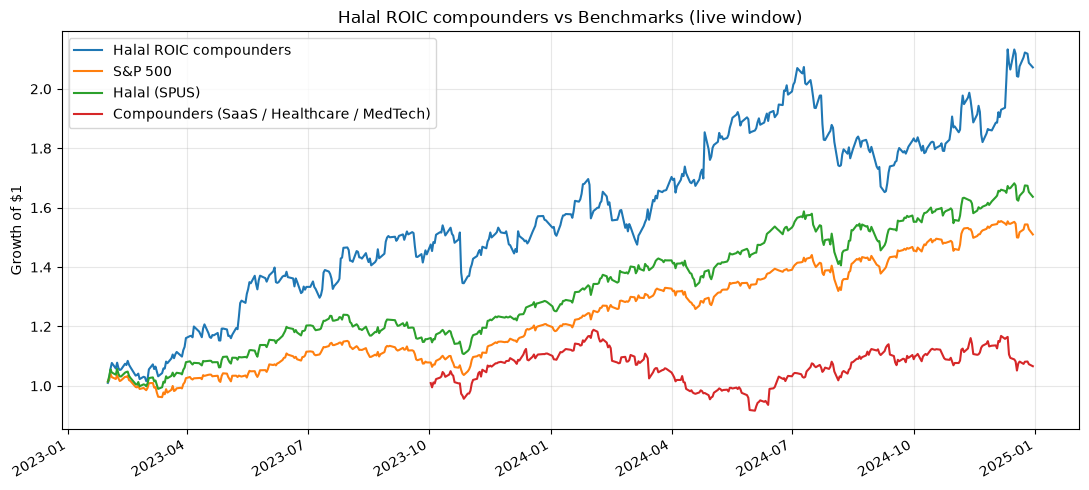

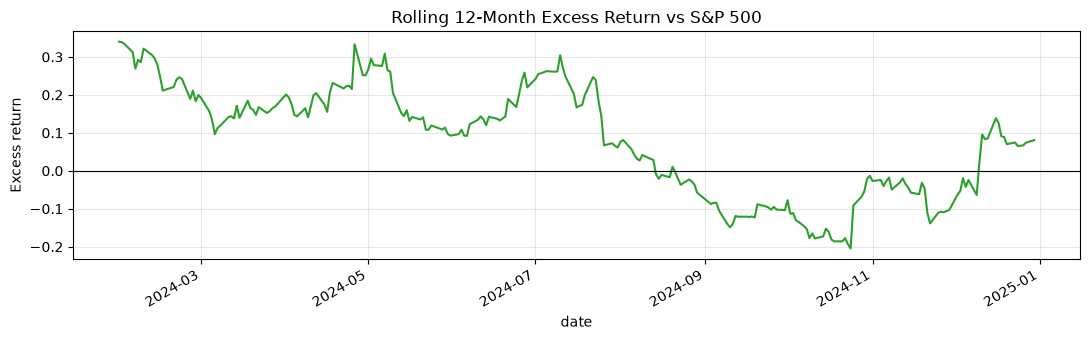

In [21]:
def benchmark_returns(ticker: str) -> pd.Series:
    px = prices[prices["symbol"] == ticker].copy()
    px["date"] = pd.to_datetime(px["date"])
    px = px.sort_values("date").set_index("date")["adj_close"]
    return px.pct_change(fill_method=None).dropna()


def align_to_live(strategy: pd.Series, benches: dict[str, pd.Series]) -> pd.DataFrame:
    """Keep only days the strategy is live, and the same days for every benchmark."""
    strategy = strategy.copy()
    strategy.index = pd.to_datetime(strategy.index)
    panel = pd.DataFrame({"strategy": strategy})
    for name, series in benches.items():
        s = series.copy()
        s.index = pd.to_datetime(s.index)
        panel[name] = s
    return panel.dropna(how="any")


from pathlib import Path

fig_dir = Path.cwd() / "figures"
if not (Path.cwd() / "code.ipynb").exists():
    fig_dir = Path.cwd() / "Research" / "papers" / "02-roic-engine" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

bench_series = {name: benchmark_returns(ticker) for name, ticker in BENCHMARKS.items()}
strategy_s = strategy_returns.set_index("date")["return"].rename(STRATEGY_LABEL)
strategy_s.index = pd.to_datetime(strategy_s.index)
robust_s = robust_returns.set_index("date")["return"].rename(ROBUST_LABEL)
robust_s.index = pd.to_datetime(robust_s.index)

main_panel = align_to_live(strategy_s, bench_series).rename(columns={"strategy": STRATEGY_LABEL})
robust_panel = align_to_live(robust_s, bench_series).rename(columns={"strategy": ROBUST_LABEL})

if main_panel.empty:
    n_live = int(strategy_s.notna().sum())
    n_held = 0 if selections.empty else int(selections["as_of"].nunique())
    raise RuntimeError(
        "No overlapping live days between the strategy and benchmarks. "
        f"Strategy has {n_live} live return days; holdings log has {n_held} rebalance months. "
        "Re-run the ROIC history + backtest cells after the attach_latest_roic fix."
    )

print(
    "Live window (main strategy): "
    f"{main_panel.index.min().date()} → {main_panel.index.max().date()}  "
    f"({len(main_panel)} trading days)"
)
if not robust_panel.empty:
    print(
        "Live window (SaaS / Healthcare / MedTech): "
        f"{robust_panel.index.min().date()} → {robust_panel.index.max().date()}  "
        f"({len(robust_panel)} trading days)"
    )

rows = [calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)]
if not robust_panel.empty:
    rows.append(calc_performance_stats(robust_panel[ROBUST_LABEL], ROBUST_LABEL))
for name in BENCHMARKS:
    rows.append(calc_performance_stats(main_panel[name], name))

performance = pd.DataFrame(rows).set_index("Strategy")
formatters = {
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Sortino": "{:.2f}",
    "Max Drawdown": "{:.2%}",
    "Calmar": "{:.2f}",
}
display(performance.style.format(formatters))

# Cumulative growth of $1 over the live window
plot_panel = main_panel.copy()
if not robust_panel.empty:
    plot_panel = plot_panel.join(robust_panel[[ROBUST_LABEL]], how="left")
equity_curves = (1 + plot_panel).cumprod()
equity_curves.plot(figsize=(11, 5), title="Halal ROIC compounders vs Benchmarks (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "equity-curves.png", dpi=140)
plt.show()

# Rolling 12-month excess return vs S&P 500
if "S&P 500" in main_panel.columns:
    rolling_excess = (
        (1 + main_panel[STRATEGY_LABEL]).rolling(252).apply(np.prod, raw=True)
        - (1 + main_panel["S&P 500"]).rolling(252).apply(np.prod, raw=True)
    )
    rolling_excess.plot(figsize=(11, 3.5), color="tab:green", title="Rolling 12-Month Excess Return vs S&P 500")
    plt.axhline(0, color="black", linewidth=0.8)
    plt.ylabel("Excess return")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "rolling-excess.png", dpi=140)
    plt.show()


## Step 8 — How bumpy was the ride, and in which years?

The headline table compresses the sample into one number. These views unpack it:

- **Drawdown** — from each peak, how far $1 fell before making a new high.
- **Calendar-year returns** — did one lucky year do all the work?
- **Holdings count** — how concentrated the book was each month.


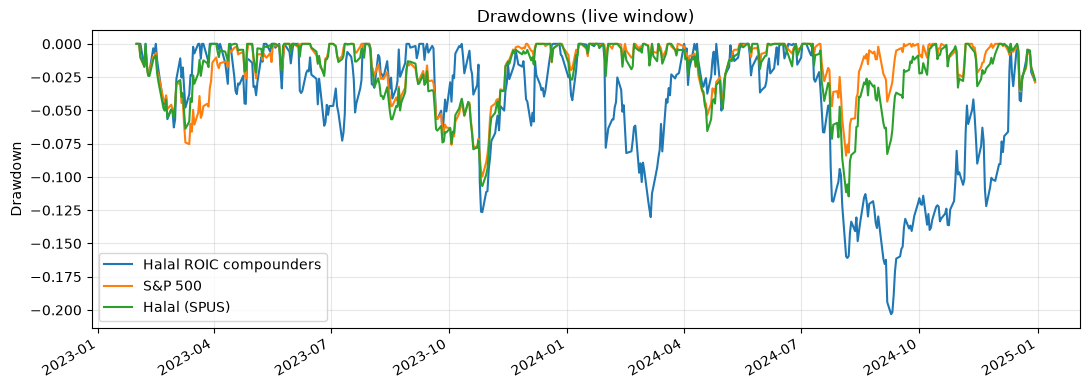

,Halal ROIC compounders,S&P 500,Halal (SPUS)
Year,,,
2023,55.25%,20.46%,28.19%
2024,33.49%,25.34%,27.67%


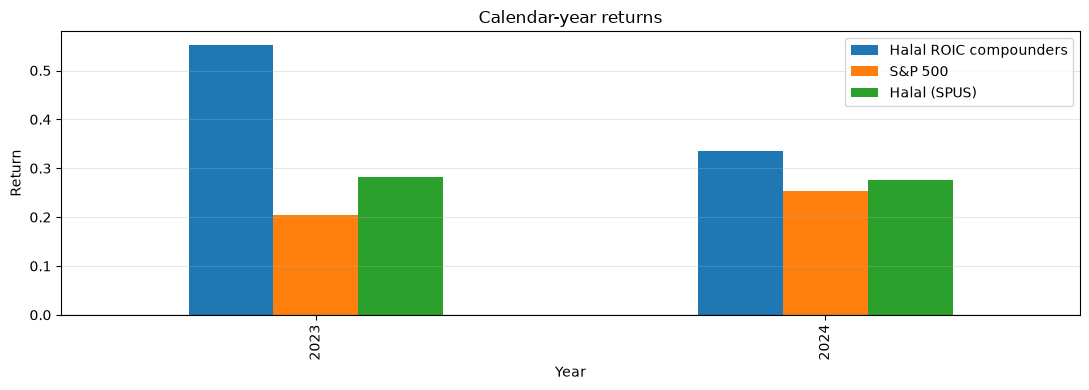

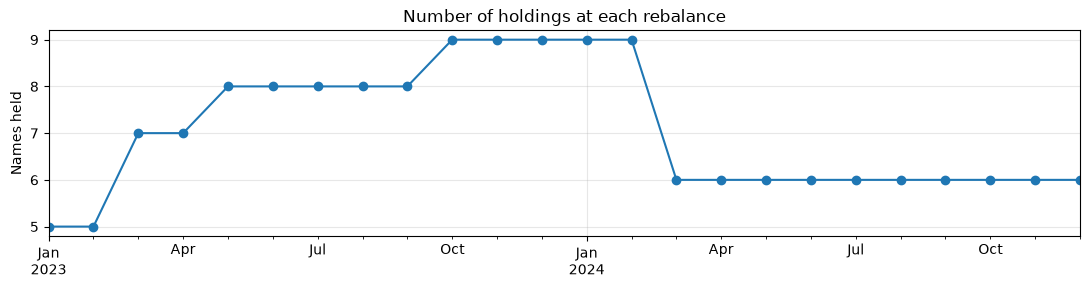

Holdings: min=5  median=6  max=9


In [22]:
# Drawdowns from running peaks (live window)
equity_live = (1 + main_panel).cumprod()
drawdowns = equity_live / equity_live.cummax() - 1
drawdowns.plot(figsize=(11, 4), title="Drawdowns (live window)")
plt.ylabel("Drawdown")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "drawdowns.png", dpi=140)
plt.show()

# Calendar-year returns
yearly = (1 + main_panel).resample("YE").prod() - 1
yearly.index = yearly.index.year
yearly.index.name = "Year"
display(yearly.style.format("{:.2%}").set_caption("Calendar-year returns (live window)"))

yearly.plot(kind="bar", figsize=(11, 4), title="Calendar-year returns")
plt.ylabel("Return")
plt.axhline(0, color="black", linewidth=0.8)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "calendar-year-returns.png", dpi=140)
plt.show()

# How many names were held each month
if selections.empty:
    print("No holdings log — skip concentration chart.")
else:
    holdings_count = (
        selections.groupby("as_of")["symbol"]
        .nunique()
        .sort_index()
    )
    holdings_count.index = pd.to_datetime(holdings_count.index)
    holdings_count.plot(
        figsize=(11, 3),
        marker="o",
        title="Number of holdings at each rebalance",
    )
    plt.ylabel("Names held")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "holdings-count.png", dpi=140)
    plt.show()
    print(
        f"Holdings: min={int(holdings_count.min())}  "
        f"median={holdings_count.median():.0f}  "
        f"max={int(holdings_count.max())}"
    )


## Step 9 — Does higher ROIC actually compound more?

Two cuts inside the Halal universe:

1. **ROIC quintiles.** Split every Halal name with a usable ROIC into five cap-weighted buckets. **Q1** = highest ROIC. If return on capital is a real quality signal, Q1 should beat Q5.
2. **Reinvestment split among high-ROIC names.** Take the names that already clear **ROIC `> 15%`** and split them into high vs low reinvestment (median). The live rule is the high-reinvestment half. If ploughing capital back in at a high ROIC is what compounds, the high-reinvestment sleeve should beat the low-reinvestment sleeve.


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
Q1,27.75%,19.29%,1.26,1.89,-14.06%,1.97
Q2,43.38%,25.98%,1.44,1.98,-20.46%,2.12
Q3,22.94%,20.96%,1.00,1.30,-18.71%,1.23
Q4,5.18%,14.08%,0.29,0.43,-17.57%,0.30
Q5,10.93%,24.45%,0.46,0.72,-20.63%,0.53


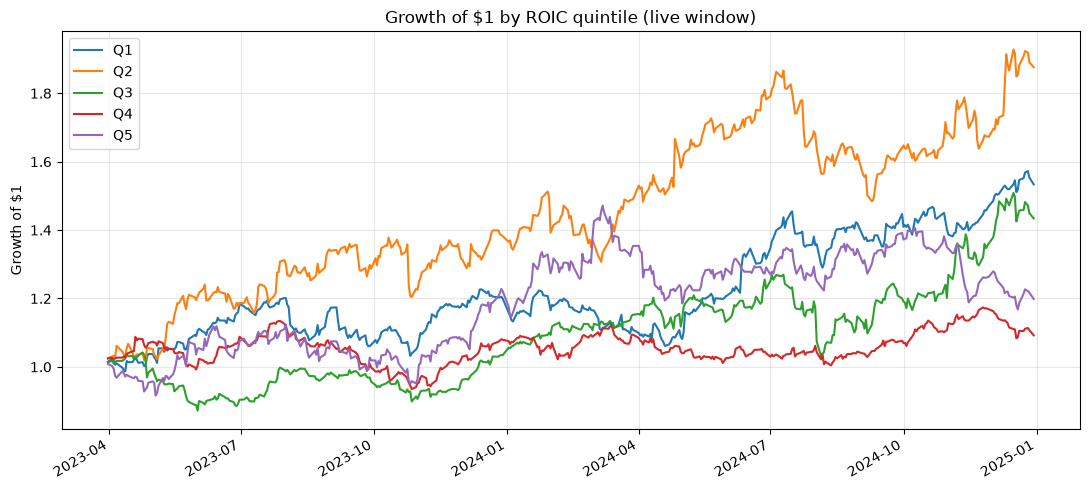

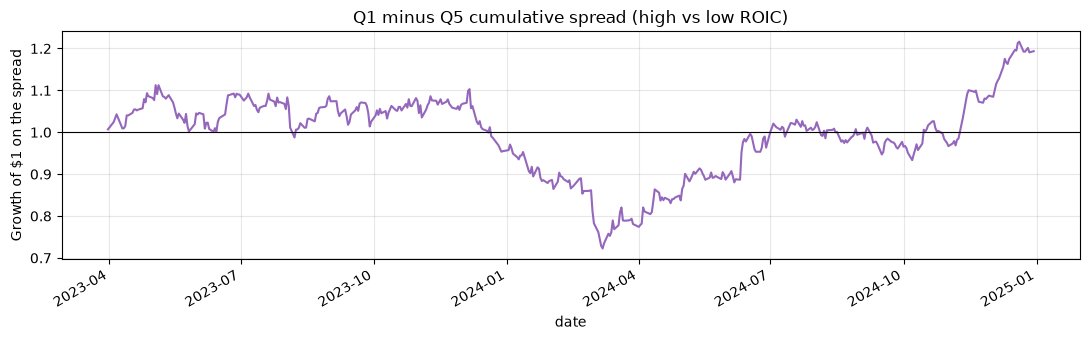

Q1−Q5 annualized spread: 13.00%  ·  hit rate (Q1 beats Q5 that day): 54.5%


,CAGR,Volatility,Sharpe,Sortino,Max Drawdown,Calmar
Strategy,,,,,,
High ROIC + high reinvestment,41.44%,25.83%,1.39,1.91,-20.32%,2.04
High ROIC + low reinvestment,30.47%,19.12%,1.38,2.09,-13.72%,2.22


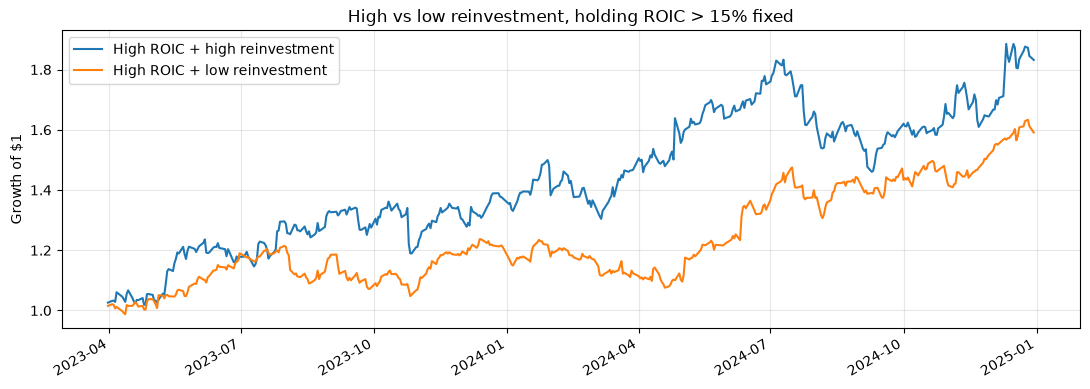

In [23]:
def cap_weighted_returns(
    weights_by_date: dict[date, pd.Series],
    daily_returns: pd.DataFrame,
) -> pd.Series:
    """Daily returns from a {rebalance_date: symbol-weight Series} map."""
    rebal = sorted(weights_by_date)
    active_w = pd.Series(dtype=float)
    last: date | None = None
    live = False
    rows: list[float] = []

    for dt in daily_returns.index:
        prior = [d for d in rebal if pd.Timestamp(d) <= dt]
        if prior and prior[-1] != last:
            active_w = weights_by_date.get(prior[-1], pd.Series(dtype=float))
            last = prior[-1]
            if not active_w.empty:
                live = True
        if not live:
            rows.append(np.nan)
            continue
        held = [s for s in active_w.index if s in daily_returns.columns]
        w = active_w.reindex(held).astype(float)
        w = w[w > 0]
        if w.empty:
            rows.append(0.0)
            continue
        w = w / w.sum()
        day_ret = (daily_returns.loc[dt, w.index] * w).sum(skipna=True)
        rows.append(0.0 if pd.isna(day_ret) else float(day_ret))

    return pd.Series(rows, index=pd.to_datetime(daily_returns.index), name="return")


N_Q = 5
scored_panel = attach_latest_roic(metrics, roic_history)
screener = AAOIFIScreener(debt_threshold=DEBT_THRESHOLD)
price_panel = (
    prices[prices["symbol"].isin(eligible_universe)]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
stock_returns = price_panel.pct_change(fill_method=None)


def halal_scored(as_of: date, require_high_roic: bool = False) -> pd.DataFrame:
    snap = scored_panel[pd.to_datetime(scored_panel["as_of"]).dt.date == pd.Timestamp(as_of).date()].copy()
    if snap.empty:
        return snap
    screened = screener.evaluate_compliance(snap)
    snap = snap.drop(columns=[c for c in ("debt_ratio", "cash_ratio", "receivables_ratio") if c in snap.columns])
    passed = snap.merge(screened, on="symbol", how="inner")
    passed = passed[passed["is_compliant"].fillna(False)].copy()
    passed = score_compounding(passed)
    passed = passed[
        passed["roic"].notna()
        & np.isfinite(passed["roic"])
        & (passed["roic"] < 5.0)
        & (passed["nopat"] > 0)
        & (passed["invested_capital"] > 0)
        & (pd.to_numeric(passed["market_cap"], errors="coerce") > 0)
    ]
    if require_high_roic:
        passed = passed[
            (passed["roic"] > ROIC_MIN)
            & passed["reinvestment_rate"].notna()
            & np.isfinite(passed["reinvestment_rate"])
        ]
    return passed


quantile_w: dict[int, dict[date, pd.Series]] = {q: {} for q in range(1, N_Q + 1)}
for as_of in rebalance_dates:
    ranked = halal_scored(as_of, require_high_roic=False)
    if ranked.empty:
        continue
    ranked = ranked.sort_values("roic", ascending=False)
    n = len(ranked)
    if n < N_Q * 2:
        continue
    edges = np.linspace(0, n, N_Q + 1).astype(int)
    for q in range(N_Q):
        chunk = assign_cap_weights(ranked.iloc[edges[q] : edges[q + 1]].copy())
        quantile_w[q + 1][as_of] = chunk.set_index("symbol")["weight"].astype(float)

quantile_returns = pd.DataFrame(
    {
        f"Q{q}": cap_weighted_returns(quantile_w[q], stock_returns)
        for q in range(1, N_Q + 1)
    }
)
quantile_live = quantile_returns.reindex(main_panel.index).dropna(how="any")

q_rows = [calc_performance_stats(quantile_live[col], col) for col in quantile_live.columns]
q_stats = pd.DataFrame(q_rows).set_index("Strategy")
display(q_stats.style.format(formatters).set_caption(
    "ROIC quintiles inside the Halal universe  ·  Q1 = highest ROIC, cap-weighted"
))

q_equity = (1 + quantile_live).cumprod()
q_equity.plot(figsize=(11, 5), title="Growth of $1 by ROIC quintile (live window)")
plt.ylabel("Growth of $1")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "quintile-growth.png", dpi=140)
plt.show()

if {"Q1", "Q5"}.issubset(quantile_live.columns):
    spread = quantile_live["Q1"] - quantile_live["Q5"]
    spread_equity = (1 + spread).cumprod()
    spread_equity.plot(
        figsize=(11, 3.5),
        color="tab:purple",
        title="Q1 minus Q5 cumulative spread (high vs low ROIC)",
    )
    plt.axhline(1.0, color="black", linewidth=0.8)
    plt.ylabel("Growth of $1 on the spread")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "quintile-spread.png", dpi=140)
    plt.show()
    print(
        f"Q1−Q5 annualized spread: {spread.mean() * 252:.2%}  ·  "
        f"hit rate (Q1 beats Q5 that day): {(quantile_live['Q1'] > quantile_live['Q5']).mean():.1%}"
    )

# High vs low reinvestment among names that already clear ROIC > 15%
high_reinv_w: dict[date, pd.Series] = {}
low_reinv_w: dict[date, pd.Series] = {}
for as_of in rebalance_dates:
    pool = halal_scored(as_of, require_high_roic=True)
    pool = pool[pool["reinvestment_rate"] > 0]
    if len(pool) < 10:
        continue
    mid = pool["reinvestment_rate"].median()
    high = assign_cap_weights(pool[pool["reinvestment_rate"] >= mid].copy())
    low = assign_cap_weights(pool[pool["reinvestment_rate"] < mid].copy())
    if not high.empty:
        high_reinv_w[as_of] = high.set_index("symbol")["weight"].astype(float)
    if not low.empty:
        low_reinv_w[as_of] = low.set_index("symbol")["weight"].astype(float)

reinv_returns = pd.DataFrame(
    {
        "High ROIC + high reinvestment": cap_weighted_returns(high_reinv_w, stock_returns),
        "High ROIC + low reinvestment": cap_weighted_returns(low_reinv_w, stock_returns),
    }
)
reinv_live = reinv_returns.reindex(main_panel.index).dropna(how="any")
if reinv_live.empty:
    print("Not enough high-ROIC names to split on reinvestment.")
else:
    r_rows = [calc_performance_stats(reinv_live[col], col) for col in reinv_live.columns]
    display(
        pd.DataFrame(r_rows).set_index("Strategy").style.format(formatters).set_caption(
            "Reinvestment split inside the Halal ROIC>15% pool  ·  cap-weighted"
        )
    )
    (1 + reinv_live).cumprod().plot(
        figsize=(11, 4),
        title="High vs low reinvestment, holding ROIC > 15% fixed",
    )
    plt.ylabel("Growth of $1")
    plt.xlabel("")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fig_dir / "reinvestment-split.png", dpi=140)
    plt.show()


## Step 10 — Attribution: stock picking or a hidden sector bet?

White-paper section 4 asks whether the result is really high-ROIC compounding, or just “we accidentally owned more SaaS and MedTech in a mega-cap boom.”

- **Beta** — if the market moves 1%, how much does our book tend to move?
- **Alpha** — leftover return after subtracting that market-related piece.
- **Tracking error** — how differently we wiggle versus the benchmark.
- **Focus mix** — average weight in SaaS / Healthcare / MedTech versus the equal-weight Halal S&P basket. This is the sector bet the paper is designed to measure.
- **GICS mix** — broader industry weights for the same comparison.


,Alpha (ann.),Beta,R²,Tracking error,Information ratio
Benchmark,,,,,
S&P 500,13.83%,1.26,0.39,20.29%,0.94
Halal (SPUS),10.88%,1.15,0.45,19.12%,0.76


,Compounder book (avg. month),Halal universe (equal weight),Delta
Other,93.8%,75.5%,18.3%
SaaS,5.6%,10.2%,-4.6%
MedTech,1.0%,10.2%,-9.2%
Healthcare,0.0%,4.1%,-4.1%


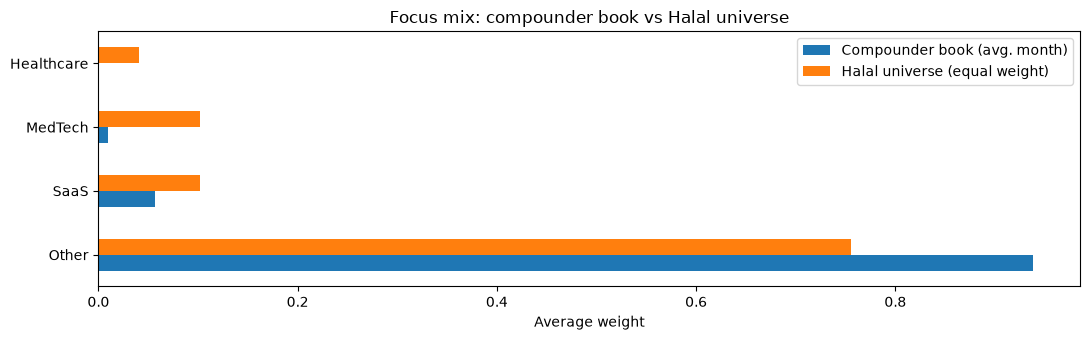

,Compounder book (avg. month),Halal universe (equal weight),Delta
Communication Services,89.3%,8.2%,81.1%
Technology,15.7%,22.4%,-6.8%
Consumer Cyclical,2.3%,14.3%,-12.0%
Healthcare,1.0%,14.3%,-13.3%
Basic Materials,0.6%,4.1%,-3.5%
Utilities,0.0%,12.2%,-12.2%
Industrials,0.0%,8.2%,-8.2%
Financial Services,0.0%,6.1%,-6.1%
Real Estate,0.0%,4.1%,-4.1%
Energy,0.0%,4.1%,-4.1%


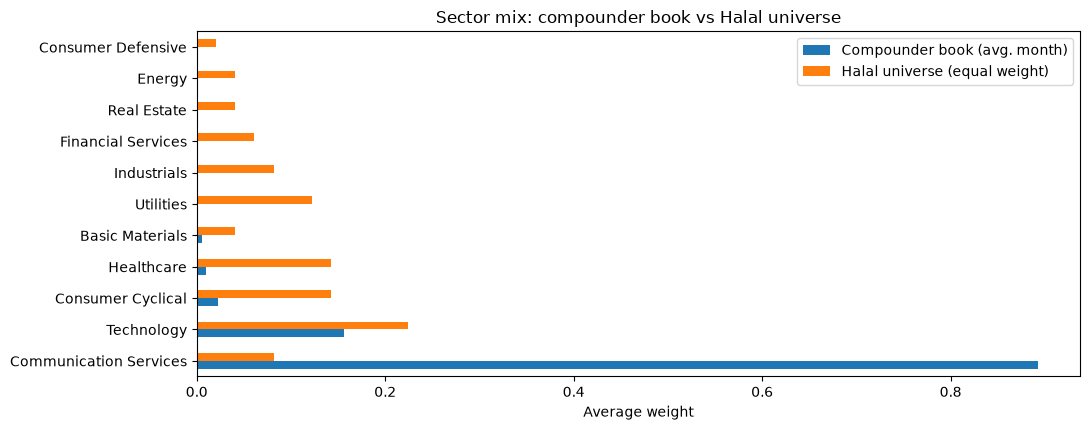

In [24]:
def capm_attribution(strategy: pd.Series, benchmark: pd.Series, rf: float = RISK_FREE_RATE) -> dict:
    """Alpha, beta, R², tracking error vs one benchmark (daily, then annualized)."""
    aligned = pd.concat([strategy, benchmark], axis=1, keys=["y", "x"]).dropna()
    rf_d = rf / 252
    ye = aligned["y"] - rf_d
    xe = aligned["x"] - rf_d
    var_x = xe.var()
    beta = float(ye.cov(xe) / var_x) if var_x > 0 else np.nan
    alpha_d = float(ye.mean() - beta * xe.mean()) if pd.notna(beta) else np.nan
    resid = ye - alpha_d - beta * xe
    r2 = 1 - resid.var() / ye.var() if ye.var() > 0 else np.nan
    excess = aligned["y"] - aligned["x"]
    te = float(excess.std() * np.sqrt(252))
    ir = float(excess.mean() * 252 / te) if te > 0 else np.nan
    return {
        "Alpha (ann.)": alpha_d * 252,
        "Beta": beta,
        "R²": r2,
        "Tracking error": te,
        "Information ratio": ir,
    }


attr_rows = []
for bench_name in BENCHMARKS:
    row = capm_attribution(main_panel[STRATEGY_LABEL], main_panel[bench_name])
    row["Benchmark"] = bench_name
    attr_rows.append(row)
attr = pd.DataFrame(attr_rows).set_index("Benchmark")
display(
    attr.style.format({
        "Alpha (ann.)": "{:.2%}",
        "Beta": "{:.2f}",
        "R²": "{:.2f}",
        "Tracking error": "{:.2%}",
        "Information ratio": "{:.2f}",
    }).set_caption("Halal ROIC compounders vs each benchmark (live window)")
)

if selections.empty:
    print("No holdings log — skip sector mix.")
else:
    def average_weight_by(label_map: dict[str, str], universe_labels: pd.Series) -> pd.DataFrame:
        month_weights = []
        for as_of, snap in selections.groupby("as_of"):
            w = snap["weight"] if "weight" in snap.columns else 1 / len(snap)
            month_weights.append(
                snap.assign(weight=w)
                .assign(bucket=lambda d: d["symbol"].map(label_map).fillna("Unclassified"))
                .groupby("bucket")["weight"]
                .sum()
            )
        strat_w = pd.concat(month_weights, axis=1).mean(axis=1).rename("Compounder book (avg. month)")
        univ_w = universe_labels.value_counts(normalize=True).rename("Halal universe (equal weight)")
        mix = pd.concat([strat_w, univ_w], axis=1).fillna(0.0)
        mix["Delta"] = mix["Compounder book (avg. month)"] - mix["Halal universe (equal weight)"]
        return mix.sort_values("Compounder book (avg. month)", ascending=False)

    focus_mix = average_weight_by(
        focus_map,
        pd.Series({s: focus_map.get(s, "Other") for s in eligible_universe}),
    )
    display(focus_mix.style.format("{:.1%}").set_caption(
        "Average SaaS / Healthcare / MedTech weights  ·  delta = strategy minus Halal universe"
    ))
    focus_mix.drop(columns="Delta").plot(
        kind="barh",
        figsize=(11, 3.5),
        title="Focus mix: compounder book vs Halal universe",
    )
    plt.xlabel("Average weight")
    plt.tight_layout()
    plt.savefig(fig_dir / "focus-mix.png", dpi=140)
    plt.show()

    gics_map = gics["gics_sector"].to_dict()
    sector_mix = average_weight_by(
        gics_map,
        pd.Series({s: gics_map.get(s, "Unclassified") for s in eligible_universe}),
    )
    display(sector_mix.style.format("{:.1%}").set_caption(
        "Average GICS sector weights  ·  delta = strategy minus Halal universe"
    ))
    sector_mix.drop(columns="Delta").plot(
        kind="barh",
        figsize=(11, max(4, 0.4 * len(sector_mix))),
        title="Sector mix: compounder book vs Halal universe",
    )
    plt.xlabel("Average weight")
    plt.tight_layout()
    plt.savefig(fig_dir / "sector-mix.png", dpi=140)
    plt.show()


## Step 11 — Friction: turnover, trading costs, purification

A paper result that ignores costs is an upper bound. This section asks what is left after three real-world leaks:

1. **Turnover** — each month we sell some names and buy others. High turnover means more trading.
2. **Trading cost** — we subtract `COST_BPS` (default 10 basis points, i.e. 0.10%) on each one-way trade.
3. **Purification** — for Halal portfolios, a slice of dividend income tied to impure revenue is given away. That is a drag the S&P 500 does not have.


Item,Value
Rebalances with holdings,24
Average names held,7.0
Annualized one-way turnover,67.1%
Assumed cost per one-way trade,10 bps
Estimated annual trading-cost drag,0.07%
CAGR gross of trading costs,46.37%
CAGR net of trading costs,46.20%


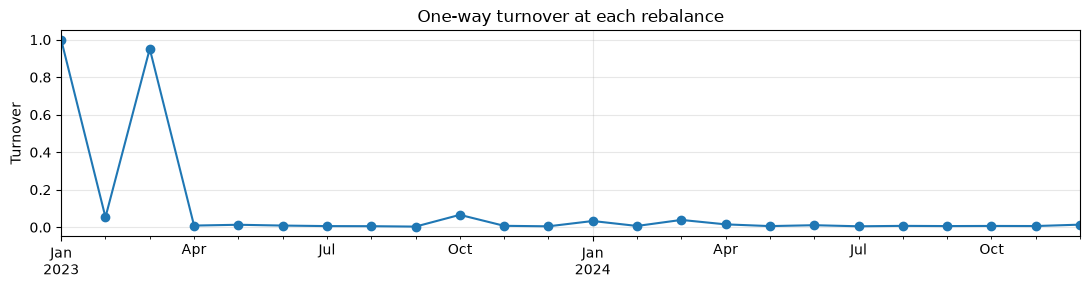

Fetching dividend purification for names the strategy held …
Dividend events while held: 19  ·  annualized purification drag ≈ 0.00%


,symbol,ex_date,dividend,impure_ratio,purification_amount
0,A,2023-04-03 00:00:00,0.225,0.13%,0.0003
1,A,2023-06-30 00:00:00,0.225,0.13%,0.0003
2,A,2023-10-02 00:00:00,0.225,0.13%,0.0003
3,A,2023-12-29 00:00:00,0.236,0.13%,0.0003
4,A,2024-04-01 00:00:00,0.236,0.75%,0.0018
5,A,2024-07-02 00:00:00,0.236,0.75%,0.0018
6,A,2024-10-01 00:00:00,0.236,0.75%,0.0018
7,A,2024-12-31 00:00:00,0.248,0.75%,0.0019
8,AAPL,2023-02-10 00:00:00,0.230,0.72%,0.0016
9,AAPL,2023-05-12 00:00:00,0.240,0.72%,0.0017


In [25]:
def one_way_turnover(old: dict[str, float], new: dict[str, float]) -> float:
    """Half L1 distance between two weight books (0 = no trades, 1 = full replace)."""
    if not new:
        return 0.0
    if not old:
        return 1.0
    names = set(old) | set(new)
    return 0.5 * sum(abs(new.get(s, 0.0) - old.get(s, 0.0)) for s in names)


if selections.empty:
    raise RuntimeError("No holdings log — re-run the backtest cell first.")

if "price_panel" not in globals():
    price_panel = (
        prices[prices["symbol"].isin(eligible_universe)]
        .pivot(index="date", columns="symbol", values="adj_close")
        .sort_index()
        .ffill()
    )

rebal_order = sorted(selections["as_of"].unique())
turnover_rows = []
prev: dict[str, float] = {}
for as_of in rebal_order:
    snap = selections.loc[selections["as_of"] == as_of]
    if "weight" in snap.columns:
        curr = snap.set_index("symbol")["weight"].astype(float).to_dict()
    else:
        curr = {s: 1.0 / len(snap) for s in snap["symbol"]}
    turnover_rows.append({"as_of": pd.Timestamp(as_of), "one_way": one_way_turnover(prev, curr), "n": len(curr)})
    prev = curr

turnover = pd.DataFrame(turnover_rows).set_index("as_of")
months = max(len(turnover) - 1, 1)
annual_turnover = turnover["one_way"].iloc[1:].sum() * (12 / months) if len(turnover) > 1 else np.nan
cost_drag_ann = annual_turnover * COST_BPS / 10_000

cost_on_day = pd.Series(0.0, index=main_panel.index)
for as_of, row in turnover.iterrows():
    hit = main_panel.index[main_panel.index >= as_of]
    if len(hit):
        cost_on_day.loc[hit[0]] += float(row["one_way"]) * COST_BPS / 10_000

net_returns = main_panel[STRATEGY_LABEL] - cost_on_day
net_stats = calc_performance_stats(net_returns, f"{STRATEGY_LABEL} net of {COST_BPS} bps")
gross_cagr = calc_performance_stats(main_panel[STRATEGY_LABEL], STRATEGY_LABEL)["CAGR"]

friction = pd.DataFrame(
    {
        "Item": [
            "Rebalances with holdings",
            "Average names held",
            "Annualized one-way turnover",
            "Assumed cost per one-way trade",
            "Estimated annual trading-cost drag",
            "CAGR gross of trading costs",
            "CAGR net of trading costs",
        ],
        "Value": [
            f"{len(turnover)}",
            f"{turnover['n'].mean():.1f}",
            f"{annual_turnover:.1%}",
            f"{COST_BPS} bps",
            f"{cost_drag_ann:.2%}",
            f"{gross_cagr:.2%}",
            f"{net_stats['CAGR']:.2%}",
        ],
    }
)
display(friction.style.hide(axis="index"))

turnover["one_way"].plot(figsize=(11, 3), marker="o", title="One-way turnover at each rebalance")
plt.ylabel("Turnover")
plt.xlabel("")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "turnover.png", dpi=140)
plt.show()

# Purification drag on dividends received while a name was held
print("Fetching dividend purification for names the strategy held …")
held_symbols = sorted(selections["symbol"].unique())
try:
    purified = hq.purify_dividends(
        held_symbols,
        start=str(main_panel.index.min().date()),
        end=END,
    )
except Exception as exc:
    purified = pd.DataFrame()
    print(f"Purification lookup failed ({exc}). Skipping drag estimate.")

if purified.empty:
    print("No purification rows returned. Report this as a data gap in the paper, not as 0% drag.")
else:
    held_flags = []
    for as_of, snap in selections.groupby("as_of"):
        held_flags.append(pd.DataFrame({"as_of": pd.Timestamp(as_of), "symbol": snap["symbol"].tolist()}))
    held_log = pd.concat(held_flags, ignore_index=True)

    purified = purified.copy()
    purified["ex_date"] = pd.to_datetime(purified["ex_date"])
    px = price_panel.copy()
    px.index = pd.to_datetime(px.index)

    drag_rows = []
    for _, div in purified.iterrows():
        symbol = div["symbol"]
        ex = div["ex_date"]
        prior_rebal = held_log.loc[held_log["as_of"] <= ex]
        if prior_rebal.empty:
            continue
        last_asof = prior_rebal["as_of"].max()
        that_book = set(held_log.loc[held_log["as_of"] == last_asof, "symbol"])
        if symbol not in that_book:
            continue
        if symbol not in px.columns:
            continue
        hist = px.loc[:ex, symbol].dropna()
        if hist.empty or hist.iloc[-1] <= 0:
            continue
        w_snap = selections.loc[
            (selections["as_of"] == last_asof.date())
            | (pd.to_datetime(selections["as_of"]) == last_asof)
        ]
        if "weight" in w_snap.columns and symbol in set(w_snap["symbol"]):
            weight = float(w_snap.loc[w_snap["symbol"] == symbol, "weight"].iloc[0])
        else:
            weight = 1 / len(that_book)
        amount = div.get("purification_amount")
        if pd.isna(amount):
            continue
        drag_rows.append(float(amount) / float(hist.iloc[-1]) * weight)

    years = len(main_panel) / 252
    purify_drag = (sum(drag_rows) / years) if years > 0 else np.nan
    print(
        f"Dividend events while held: {len(drag_rows)}  ·  "
        f"annualized purification drag ≈ {purify_drag:.2%}"
    )
    display(
        purified[["symbol", "ex_date", "dividend", "impure_ratio", "purification_amount"]]
        .head(12)
        .style.format({"dividend": "{:.3f}", "impure_ratio": "{:.2%}", "purification_amount": "{:.4f}"}, na_rep="—")
        .set_caption("Sample purified dividends (all held names, not only ex-dates while held)")
    )


### Notes on methodology

- **Point-in-time:** `halalquant.get_financial_metrics(..., freq="ME")` uses SEC `filed_date` (or report date + 90 days for non-US filers) so rebalance decisions never use future filings.
- **ROIC source:** NOPAT, invested capital, CapEx, D&A, ΔNWC, and R&D come from yfinance annual statements with the same 90-day publication lag. Yahoo typically only stores a few annual periods, so the book may go live later than `START`.
- **ROIC definition:** `NOPAT = EBIT × (1 − effective tax rate)`, with the statutory 21% rate used when the effective rate is missing or outside `[0, 40%]`. Invested capital prefers Yahoo’s `Invested Capital` line, then book equity + debt − cash, then net PPE + operating working capital. Names with ROIC above 500% are dropped as denominator errors.
- **Reinvestment definition:** `(CapEx − D&A + ΔNWC + R&D) / NOPAT`. R&D is treated as growth investment so SaaS and MedTech are not penalised for being plant-light. A name must have a **positive** reinvestment rate to enter the ranked pool.
- **AAOIFI filter:** Sector exclusions run once up front; debt / cash / receivables screens re-run at every rebalance via `AAOIFIScreener`.
- **Selection:** Require Halal + **ROIC `> 15%`** + positive reinvestment, then keep the top `KEEP_QUANTILE` (default 50%) of that list by reinvestment rate. Weight by market cap. A month is skipped if fewer than `MIN_HOLDINGS` names survive.
- **Live-window stats:** Days before the first real holdings are missing, not 0%. CAGR, Sharpe, drawdown, and the growth chart all start when the strategy is invested. Benchmarks are sliced to that same window.
- **Quintiles:** Q1–Q5 split the same Halal names by ROIC. Q1 is highest ROIC. A second cut holds ROIC `> 15%` fixed and splits on reinvestment rate — that is the compounding hypothesis.
- **Attribution:** Alpha, beta, and tracking error are vs SPY and SPUS. Sector mix uses Yahoo GICS labels versus an equal-weight Halal S&P basket. Focus mix isolates SaaS / Healthcare / MedTech.
- **Friction:** Turnover is half the L1 weight change between monthly books. Trading-cost drag applies `COST_BPS` on each one-way turn. Purification uses `halalquant.purify_dividends` on names that appeared in the book; missing income data is a gap, not a 0% drag.
- **Robustness overlay:** `Compounders (SaaS / Healthcare / MedTech)` keeps the same ROIC + reinvestment screen, then drops every name that is not in those three buckets. `MIN_HOLDINGS` is halved on that sleeve so a thinner capital-light pool can still go live.
- **Benchmarks:** `SPY` proxies the S&P 500; `SPUS` proxies a Halal-screened US large-cap index. Swap tickers in `BENCHMARKS` if you prefer DJIM-tracking products.
- **Runtime:** `FAST_MODE = False` runs the full S&P 500 (~20–50 min depending on network). Steps 8–11 reuse that download. Figures save to `Research/papers/02-roic-engine/figures/`.
- **White-paper map:** Step 7 → section 3; Steps 8–9 → section 3 extras; Step 10 → section 4; Step 11 → section 5. Hypothesis and strategy rules (sections 1–2) are written in the paper, not computed here.
